### Capacidad Instalada por region

C:\Users\ariel\AppData\Local\Temp\ipykernel_13036\3249780215.py:151: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  regions["centroid"] = regions.geometry.centroid
INFO:pypsa.io:Imported network elec_s_9_ec_lv1_1H_demand.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


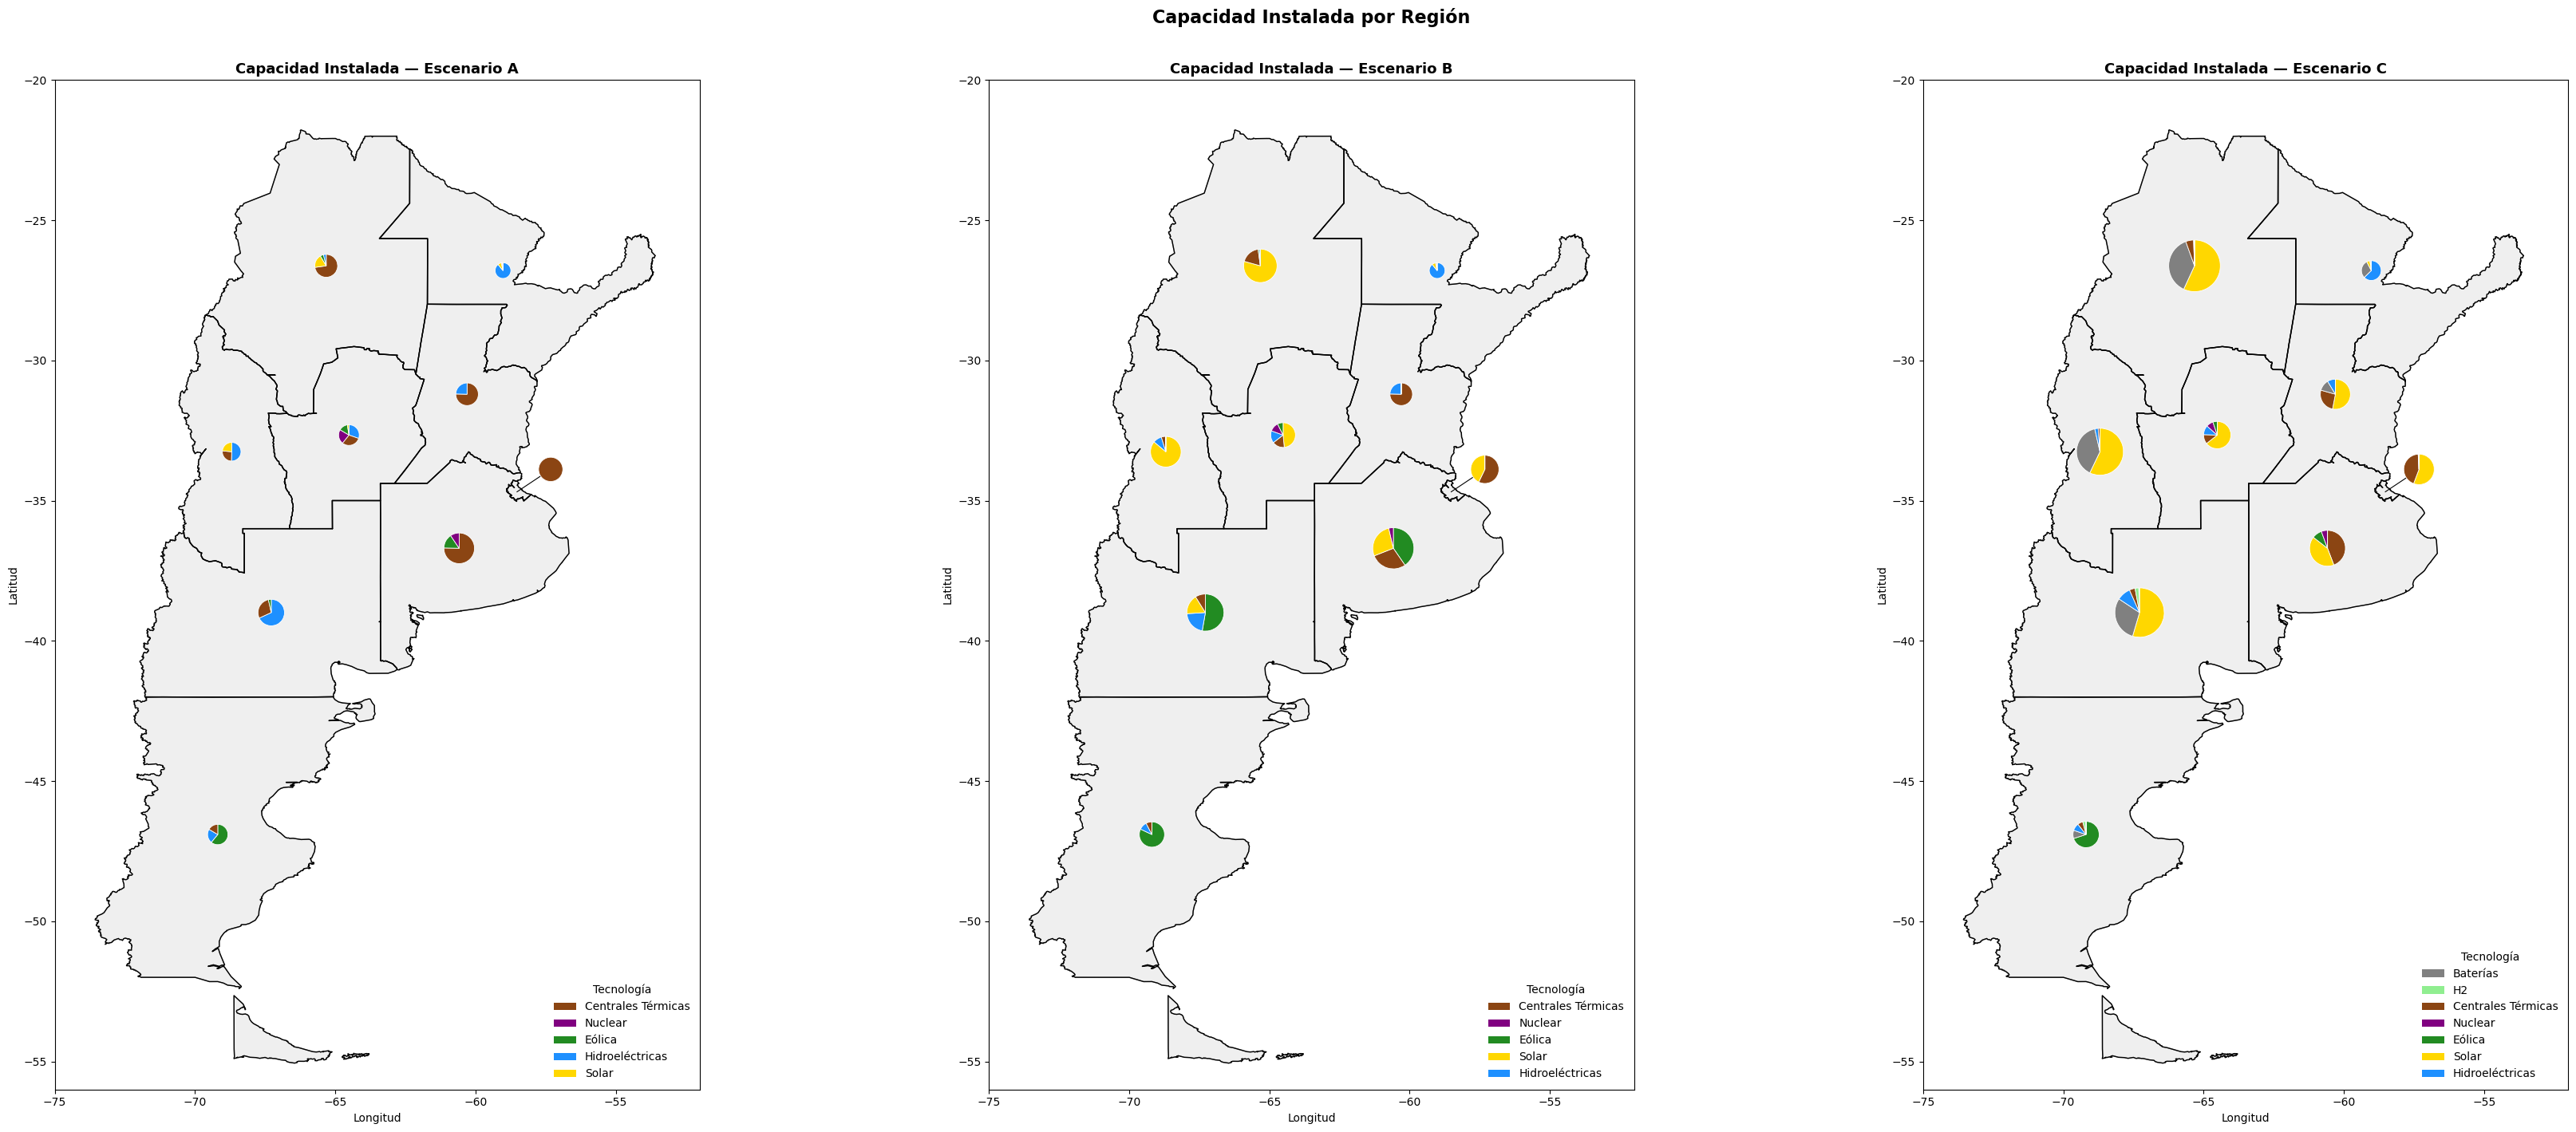

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pypsa

# ========================================
# USER INPUT
# ========================================
N1_PATH = #RED1
N2_PATH = #RED2
N3_PATH = #RED3

N1_LABEL = "Escenario A"
N2_LABEL = "Escenario B"
N3_LABEL = "Escenario C"

REGIONS_PATH = "argentina_regiones.geojson"
BUS_COL = "region"

CARRIER_COLORS = {
    "solar":               "#FFD700",
    "onwind":              "#228B22",
    "Thermal Power Plant": "#8B4513",
    "Hydropower":          "#1E90FF",
    "nuclear":             "#800080",
    "Battery":             "#808080",
    "H2":                  "#90EE90",
}

CARRIER_NAMES = {
    "solar":               "Solar",
    "onwind":              "Eólica",
    "Thermal Power Plant": "Centrales Térmicas",
    "Hydropower":          "Hidroeléctricas",
    "nuclear":             "Nuclear",
    "Battery":             "Baterías",
    "H2":                  "H2",
}
# ========================================

EXCLUDE     = {"load", "load shedding"}
HYDRO_RAW   = {"ror", "run-of-river", "hydro", "reservoir", "PHS", "phs", "pumped hydro storage"}
THERMAL_RAW = {"CCGT", "ccgt", "OCGT", "ocgt"}

def group_carrier(c):
    if c in HYDRO_RAW:                        return "Hydropower"
    if c in THERMAL_RAW:                      return "Thermal Power Plant"
    if c.lower() == "battery":                return "Battery"
    if c in ("H2 fuel cell", "H2 Fuel Cell"): return "H2"
    return c

def build_pies(n):
    gen = (
        n.generators.loc[~n.generators.carrier.isin(EXCLUDE)]
        .groupby(["bus", "carrier"])["p_nom_opt"].sum()
    )
    sto = (
        n.storage_units.loc[~n.storage_units.carrier.isin(EXCLUDE)]
        .groupby(["bus", "carrier"])["p_nom_opt"].sum()
    )
    h2_fc = (
        n.links[n.links.carrier == "H2 fuel cell"]
        .groupby("bus1")["p_nom_opt"].sum()
        .rename_axis("bus")
        .to_frame("p_nom_opt")
        .assign(carrier="H2 fuel cell")
        .reset_index()
        .set_index(["bus", "carrier"])["p_nom_opt"]
    )
    pies = pd.concat([gen, sto, h2_fc])
    pies = pies[pies > 0].reset_index()
    pies["carrier"] = pies["carrier"].map(group_carrier)
    return pies.groupby(["bus", "carrier"])["p_nom_opt"].sum()


def draw_map(ax, pies, title, regions, t_min, t_max):
    regions.plot(ax=ax, color="lightgray", alpha=0.35, edgecolor="black")
    regions.boundary.plot(ax=ax, color="black", linewidth=1)

    ax.set_xlim(-75, -52)
    ax.set_ylim(-56, -20)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    r_min, r_max = 0.35, 1.15

    def radius_scale(t):
        if t_max <= t_min:
            return (r_min + r_max) / 2
        x = np.clip((t - t_min) / (t_max - t_min), 0.0, 1.0)
        return r_min + (r_max - r_min) * np.sqrt(x)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    dx, dy = xmax - xmin, ymax - ymin

    for _, r in regions.iterrows():
        bus = "AR." + str(r[BUS_COL])
        if bus not in pies.index.get_level_values(0):
            continue

        data = pies.loc[bus].sort_values(ascending=False)
        total = float(data.sum())
        if total <= 0:
            continue

        x, y = r.centroid.x, r.centroid.y
        radius = radius_scale(total)

        if str(r[BUS_COL]) == "GBA":
            x_pie, y_pie = x + 1.2, y + 0.8
            ax.plot([x, x_pie], [y, y_pie], color="black", linewidth=0.8)
        else:
            x_pie, y_pie = x, y

        w  = (2 * radius) / dx
        h  = (2 * radius) / dy
        x0 = (x_pie - xmin) / dx - w / 2
        y0 = (y_pie - ymin) / dy - h / 2

        pie_ax = ax.inset_axes([x0, y0, w, h], transform=ax.transAxes)
        pie_ax.set_in_layout(False)
        pie_ax.set_aspect("equal")
        pie_ax.axis("off")
        pie_ax.pie(
            data.values,
            startangle=90,
            counterclock=False,
            colors=[CARRIER_COLORS.get(c, "#666666") for c in data.index],
            wedgeprops={"linewidth": 0.6, "edgecolor": "white"},
        )

    legend_carriers = [c for c in pies.index.get_level_values(1).unique()
                       if c.lower() != "biomass"]
    handles = [
        Patch(facecolor=CARRIER_COLORS.get(c, "#666666"), label=CARRIER_NAMES.get(c, c))
        for c in legend_carriers
    ]
    ax.legend(handles=handles, loc="lower right", frameon=False, title="Tecnología")


# =========================
# MAIN
# =========================

regions = gpd.read_file(REGIONS_PATH).to_crs("EPSG:4326")
regions["centroid"] = regions.geometry.centroid

networks = [(N1_PATH, N1_LABEL), (N2_PATH, N2_LABEL), (N3_PATH, N3_LABEL)]
networks = [(p, l) for p, l in networks if p]  # drop empty paths

pies_list  = [build_pies(pypsa.Network(p)) for p, _ in networks]
labels     = [l for _, l in networks]

# Shared radius scale across all maps
all_totals = pd.concat([p.groupby(level=0).sum() for p in pies_list])
t_min, t_max = float(all_totals.min()), float(all_totals.max())

n_maps = len(pies_list)
fig, axes = plt.subplots(1, n_maps, figsize=(12 * n_maps, 14))
if n_maps == 1:
    axes = [axes]

for ax, pies, label in zip(axes, pies_list, labels):
    draw_map(ax, pies, f"Capacidad Instalada — {label}", regions, t_min, t_max)

plt.suptitle("Capacidad Instalada por Región", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Flujo energetico anual entre regiones

INFO:pypsa.io:Imported network elec_s_9_ec_lv1_1H_demand.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
C:\Users\ariel\AppData\Local\Temp\ipykernel_2736\1292918513.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



TOTAL SYSTEM ANALYSIS
Time window: 2013-01-01 00:00:00 to 2014-01-01 00:00:00
Duration: 8760 hours

Regional Summary (TWh):

        production_TWh  consumption_TWh  imports_TWh  exports_TWh  \
region                                                              
AR.GBA           6.576           49.813       43.237        0.000   
AR.BAS          55.025           20.264       10.748       45.509   
AR.LIT          27.023           16.933        2.497       12.587   
AR.CEN           9.372           12.492        7.271        4.151   
AR.NOA           6.210           11.798        5.935        0.348   
AR.NEA          13.569           10.480        1.457        4.546   
AR.COM          10.218            5.141        5.406       10.483   
AR.CUY           2.833            8.500        5.935        0.267   
AR.PAT          10.140            5.546        0.075        4.669   

        net_import_TWh  
region                  
AR.GBA          43.237  
AR.BAS         -34.761  
AR.LIT        

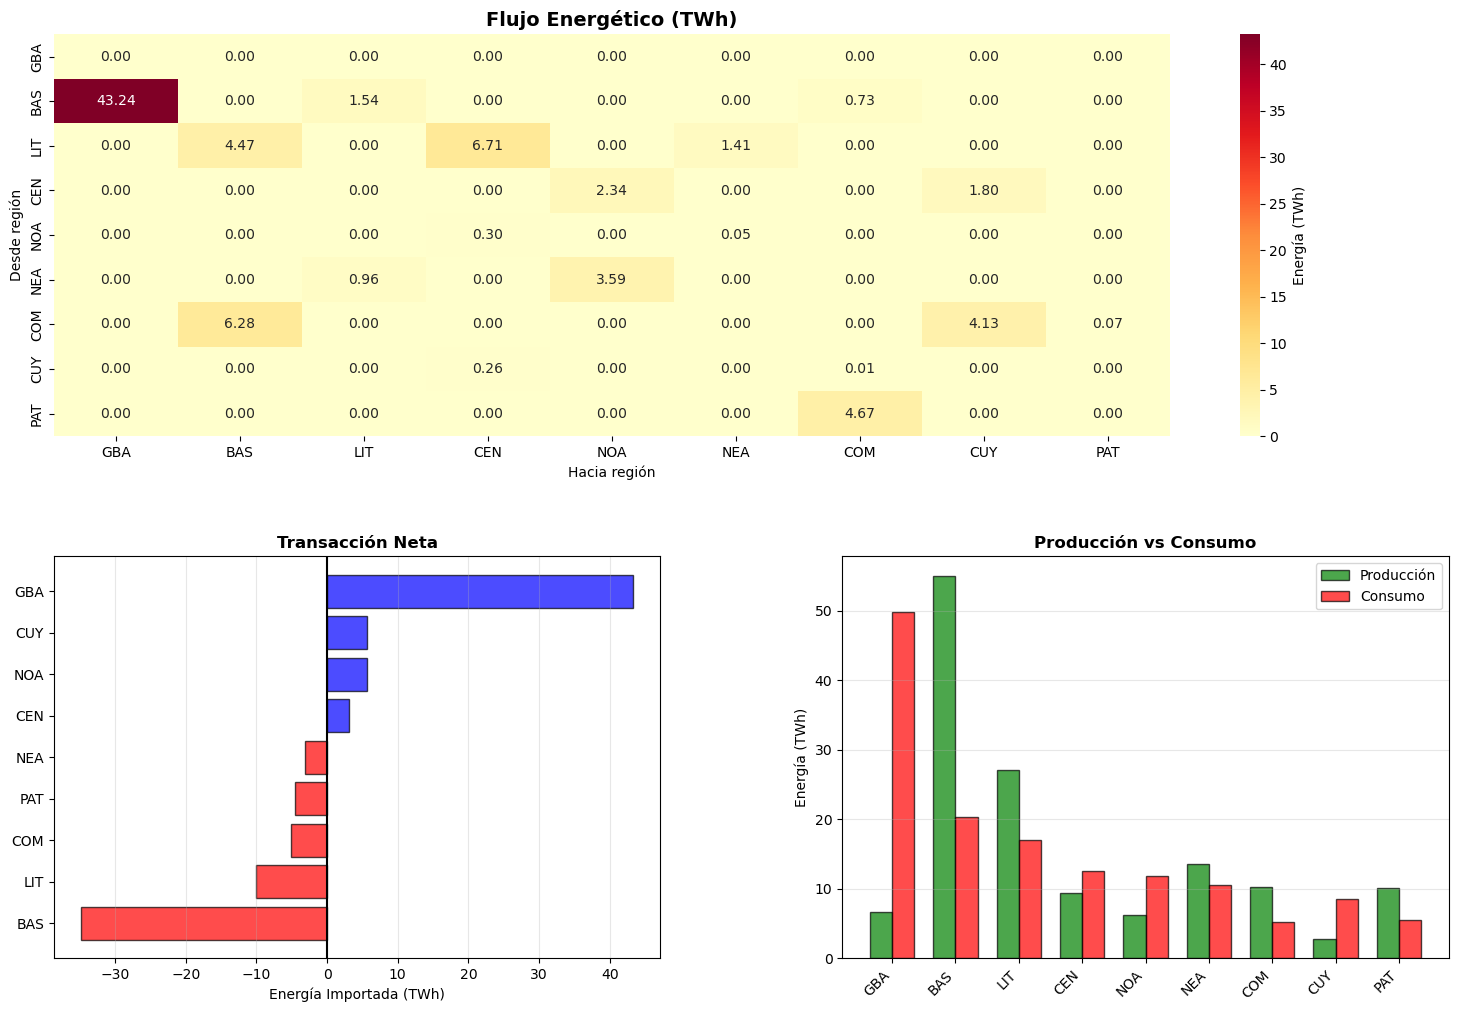

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pypsa
n = #RED
# ========================================
# USER INPUT
# ========================================
selected_bus = ""  # Change this to any bus name, or "" for total system
start = pd.Timestamp("2013-01-01 00:00:00")
end   = pd.Timestamp("2014-01-01 00:00:00")

REGION_BUSES = [
    "AR.GBA", "AR.BAS", "AR.LIT", "AR.CEN", "AR.NOA",
    "AR.NEA", "AR.COM", "AR.CUY", "AR.PAT"
]
# ========================================


def get_snapshots(n, start_time, end_time):
    """Get snapshots in the time window."""
    mask = (n.snapshots >= start_time) & (n.snapshots < end_time)
    snapshots = n.snapshots[mask]
    if len(snapshots) == 0:
        raise ValueError(f"No snapshots in window [{start_time}, {end_time})")
    return snapshots


def calculate_bus_production_consumption(n, bus_name, snapshots):
    """Calculate production and consumption for a single bus (in MWh)."""
    # Since snapshots are hourly: 1 MW for 1 hour = 1 MWh
    results = {'production': 0.0, 'consumption': 0.0}
    
    # PRODUCTION: Generators
    gens = n.generators[n.generators.bus == bus_name].index
    if len(gens) > 0:
        results['production'] = n.generators_t.p[gens].loc[snapshots].sum().sum()
    
    # Add storage discharge (positive = production)
    storage = n.storage_units[n.storage_units.bus == bus_name].index
    if len(storage) > 0:
        discharge = n.storage_units_t.p[storage].loc[snapshots].clip(lower=0).sum().sum()
        results['production'] += discharge
    
    # CONSUMPTION: Loads
    loads = n.loads[n.loads.bus == bus_name].index
    if len(loads) > 0:
        results['consumption'] = n.loads_t.p_set[loads].loc[snapshots].sum().sum()
    
    # Add storage charge (negative power = consumption)
    if len(storage) > 0:
        charge = (-n.storage_units_t.p[storage].loc[snapshots]).clip(lower=0).sum().sum()
        results['consumption'] += charge
    
    return results


def calculate_trade_matrix(n, region_buses, snapshots):
    """
    Calculate directional trade matrix between regions (in MWh).
    E[i,j] = energy flowing from region i to region j
    """
    regions = pd.Index(region_buses)
    E = pd.DataFrame(0.0, index=regions, columns=regions)
    
    # AC Lines
    for idx, line in n.lines.iterrows():
        bus0, bus1 = line['bus0'], line['bus1']
        if bus0 in regions and bus1 in regions and bus0 != bus1:
            flow = n.lines_t.p0.loc[snapshots, idx]  # MW, positive = bus0 -> bus1
            export_energy = flow.clip(lower=0).sum()  # MWh from bus0 to bus1
            import_energy = (-flow).clip(lower=0).sum()  # MWh from bus1 to bus0
            E.loc[bus0, bus1] += export_energy
            E.loc[bus1, bus0] += import_energy
    
    # DC Links (HVDC, etc.)
    if hasattr(n, 'links_t') and hasattr(n.links_t, 'p0') and len(n.links) > 0:
        for idx, link in n.links.iterrows():
            bus0, bus1 = link['bus0'], link['bus1']
            if bus0 in regions and bus1 in regions and bus0 != bus1:
                flow = n.links_t.p0.loc[snapshots, idx]  # MW, positive = bus0 -> bus1
                export_energy = flow.clip(lower=0).sum()  # MWh from bus0 to bus1
                import_energy = (-flow).clip(lower=0).sum()  # MWh from bus1 to bus0
                E.loc[bus0, bus1] += export_energy
                E.loc[bus1, bus0] += import_energy
    
    # Calculate totals
    exports = E.sum(axis=1)  # Total sent out
    imports = E.sum(axis=0)  # Total received
    net_import = imports - exports
    
    return E, imports, exports, net_import


# =========================
# MAIN ANALYSIS
# =========================

snapshots = get_snapshots(n, start, end)

if selected_bus and selected_bus != "" and selected_bus != "None":
    # ===== SINGLE BUS ANALYSIS =====
    if selected_bus not in REGION_BUSES:
        print(f"ERROR: Bus '{selected_bus}' not found")
        print(f"\nAvailable buses: {REGION_BUSES}")
        raise ValueError(f"Bus '{selected_bus}' not found")
    
    # Calculate energy balance
    results = calculate_bus_production_consumption(n, selected_bus, snapshots)
    E, imports, exports, net_import = calculate_trade_matrix(n, REGION_BUSES, snapshots)
    
    results['import'] = imports.loc[selected_bus]
    results['export'] = exports.loc[selected_bus]
    results['net_import'] = net_import.loc[selected_bus]
    
    # Print results
    print(f"\n{'='*70}")
    print(f"Energy Balance for Bus: {selected_bus}")
    print(f"Time window: {start} to {end}")
    print(f"Duration: {len(snapshots)} hours")
    print(f"{'='*70}")
    print(f"Production:  {results['production']:>15,.0f} MWh  ({results['production']/1e6:>8.3f} TWh)")
    print(f"Consumption: {results['consumption']:>15,.0f} MWh  ({results['consumption']/1e6:>8.3f} TWh)")
    print(f"Import:      {results['import']:>15,.0f} MWh  ({results['import']/1e6:>8.3f} TWh)")
    print(f"Export:      {results['export']:>15,.0f} MWh  ({results['export']/1e6:>8.3f} TWh)")
    print(f"Net Import:  {results['net_import']:>15,.0f} MWh  ({results['net_import']/1e6:>8.3f} TWh)")
    print(f"{'='*70}")
    
    # Energy balance check
    balance = (results['production'] + results['import'] - 
               results['consumption'] - results['export'])
    print(f"Balance check (should be ~0): {balance:>15,.0f} MWh ({balance/results['consumption']*100:.2f}%)")
    print(f"{'='*70}\n")
    
    # Show trade partners
    imports_from = E[selected_bus]
    imports_from = imports_from[imports_from > 1].sort_values(ascending=False)  # >1 MWh threshold
    
    exports_to = E.loc[selected_bus]
    exports_to = exports_to[exports_to > 1].sort_values(ascending=False)
    
    if len(imports_from) > 0:
        print(f"Imports from:")
        for region, value in imports_from.items():
            print(f"  {region}: {value:>12,.0f} MWh  ({value/1e6:>6.3f} TWh)")
    
    if len(exports_to) > 0:
        print(f"\nExports to:")
        for region, value in exports_to.items():
            print(f"  {region}: {value:>12,.0f} MWh  ({value/1e6:>6.3f} TWh)")
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Energy balance bar chart
    categories = ['Production', 'Consumption', 'Import', 'Export']
    values = [results['production'], results['consumption'],
              results['import'], results['export']]
    colors = ['green', 'red', 'blue', 'orange']
    
    ax1.bar(categories, [v/1e6 for v in values], color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Energy (TWh)')
    ax1.set_title(f'Energy Balance - {selected_bus}')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Supply/demand pie chart
    if results['production'] > 0 or results['import'] > 0:
        supply_labels = []
        supply_values = []
        if results['production'] > 0:
            supply_labels.append(f"Production\n{results['production']/1e6:.2f} TWh")
            supply_values.append(results['production'])
        if results['import'] > 0:
            supply_labels.append(f"Import\n{results['import']/1e6:.2f} TWh")
            supply_values.append(results['import'])
        
        ax2.pie(supply_values, labels=supply_labels, autopct='%1.1f%%',
                startangle=90, colors=['green', 'blue'])
        ax2.set_title('Energy Supply Mix')
    
    # 3. Import sources
    if len(imports_from) > 0:
        ax3.barh(imports_from.index.astype(str), imports_from.values/1e6, color='blue', alpha=0.7)
        ax3.set_xlabel('Energy (TWh)')
        ax3.set_title(f'Imports to {selected_bus}')
        ax3.grid(True, alpha=0.3, axis='x')
    else:
        ax3.text(0.5, 0.5, 'No Imports', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title(f'Imports to {selected_bus}')
    
    # 4. Export destinations
    if len(exports_to) > 0:
        ax4.barh(exports_to.index.astype(str), exports_to.values/1e6, color='orange', alpha=0.7)
        ax4.set_xlabel('Energy (TWh)')
        ax4.set_title(f'Exports from {selected_bus}')
        ax4.grid(True, alpha=0.3, axis='x')
    else:
        ax4.text(0.5, 0.5, 'No Exports', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title(f'Exports from {selected_bus}')
    
    plt.tight_layout()
    filename = f"energy_balance_{selected_bus}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved as: {filename}")
    plt.show()

else:
    # ===== TOTAL SYSTEM ANALYSIS =====
    print("\n" + "="*70)
    print("TOTAL SYSTEM ANALYSIS")
    print(f"Time window: {start} to {end}")
    print(f"Duration: {len(snapshots)} hours")
    print("="*70)
    
    # Calculate per-region production and consumption
    region_data = []
    for bus in REGION_BUSES:
        bus_results = calculate_bus_production_consumption(n, bus, snapshots)
        region_data.append({
            'region': bus,
            'production': bus_results['production'],
            'consumption': bus_results['consumption']
        })
    
    region_df = pd.DataFrame(region_data).set_index('region')
    
    # Get trade matrix
    E, imports, exports, net_import = calculate_trade_matrix(n, REGION_BUSES, snapshots)
    
    # Add trade to summary
    region_df['imports'] = imports
    region_df['exports'] = exports
    region_df['net_import'] = net_import
    
    # Convert to TWh for display
    summary_TWh = region_df / 1e6
    summary_TWh.columns = [f'{col}_TWh' for col in summary_TWh.columns]
    
    print("\nRegional Summary (TWh):\n")
    print(summary_TWh.round(3))
    
    # System totals
    total_production = region_df['production'].sum()
    total_consumption = region_df['consumption'].sum()
    print(f"\n{'='*70}")
    print(f"System Totals:")
    print(f"Total Production:  {total_production:>15,.0f} MWh  ({total_production/1e6:>8.3f} TWh)")
    print(f"Total Consumption: {total_consumption:>15,.0f} MWh  ({total_consumption/1e6:>8.3f} TWh)")
    print(f"Balance: {total_production - total_consumption:>15,.0f} MWh")
    print(f"{'='*70}\n")
    
    # Visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # 1. Trade matrix heatmap
    ax1 = fig.add_subplot(gs[0, :])
    sns.heatmap(E/1e6, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax1,
                xticklabels=[b.replace('AR.', '') for b in REGION_BUSES],
                yticklabels=[b.replace('AR.', '') for b in REGION_BUSES],
                cbar_kws={'label': 'Energía (TWh)'})
    ax1.set_title('Flujo Energético (TWh)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Hacia región')
    ax1.set_ylabel('Desde región')
    
    # 2. Net imports/exports
    ax2 = fig.add_subplot(gs[1, 0])
    net_bars = summary_TWh['net_import_TWh'].sort_values()
    colors_net = ['red' if x < 0 else 'blue' for x in net_bars]
    ax2.barh([b.replace('AR.', '') for b in net_bars.index], net_bars.values, 
             color=colors_net, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Energía Importada (TWh)')
    ax2.set_title('Transacción Neta', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.axvline(x=0, color='black', linewidth=1.5)
    
    # 3. Production vs Consumption
    ax3 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(REGION_BUSES))
    width = 0.35
    ax3.bar(x - width/2, summary_TWh['production_TWh'], width, label='Producción', 
            color='green', alpha=0.7, edgecolor='black')
    ax3.bar(x + width/2, summary_TWh['consumption_TWh'], width, label='Consumo',
            color='red', alpha=0.7, edgecolor='black')
    ax3.set_ylabel('Energía (TWh)')
    ax3.set_title('Producción vs Consumo', fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels([b.replace('AR.', '') for b in REGION_BUSES], rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    filename = "system_energy_analysis.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved as: {filename}")
    plt.show()

### Capacidad Instalada vs Despacho

INFO:pypsa.io:Imported network elec_s_9_ec_lv1_1H_demand.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units



Capacidad Instalada
Tecnología                     Cap. (MW)       Cap. (GW)       %         
----------------------------------------------------------------------
Centrales Térmicas                     23,486          23.49      57.5%
Hidroeléctricas                         9,915           9.91      24.3%
Eólica                                  4,242           4.24      10.4%
Nuclear                                 1,755           1.75       4.3%
Solar                                   1,451           1.45       3.6%
----------------------------------------------------------------------
TOTAL                                  40,849          40.85     100.0%


Despacho
Ventana: 2013-01-01 00:00:00 → 2014-01-01 00:00:00 (8760 h)
       Centrales Térmicas:      77,395,211 MWh  (77.395 TWh)  (54.9%)
          Hidroeléctricas:      32,252,845 MWh  (32.253 TWh)  (22.9%)
                  Nuclear:      15,373,798 MWh  (15.374 TWh)  (10.9%)
                   Eólico:      13,570,718 MWh  (1

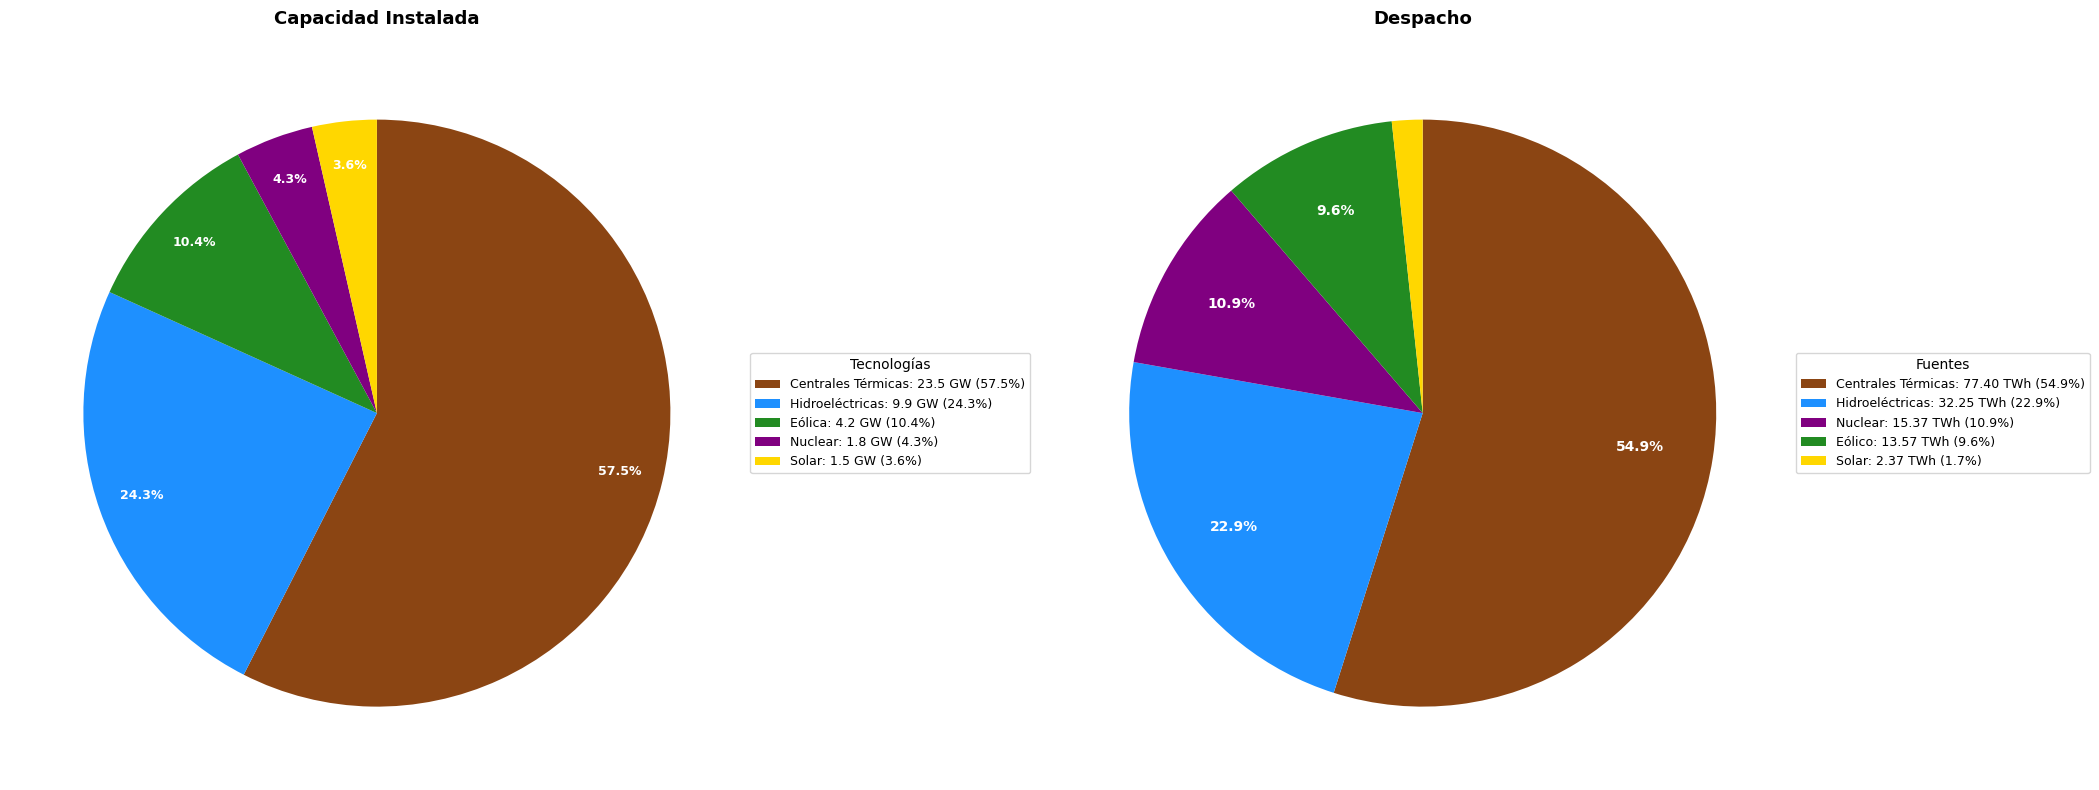

In [ ]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========================================
# USER INPUT
# ========================================
selected_bus = ""

start = pd.Timestamp("2013-01-01 00:00:00")
end   = pd.Timestamp("2014-01-01 00:00:00")

N_PATH  = #RED
N_LABEL = "Red Actual"

REGION_BUSES = [
    "AR.GBA", "AR.BAS", "AR.LIT", "AR.CEN", "AR.NOA",
    "AR.NEA", "AR.COM", "AR.CUY", "AR.PAT"
]

EXCLUDE_CARRIERS = ["load", "load shedding", "load_shedding"]

HYDRO_RAW   = {"hydro", "ror", "PHS", "phs", "pumped hydro storage"}
THERMAL_RAW = {"CCGT", "OCGT", "biomass"}

TECH_COLORS = {
    "solar":              "#FFD700",
    "OCGT":               "#FF0000",
    "CCGT":               "#8B4513",
    "battery":            "#808080",
    "onwind":             "#228B22",
    "hydro":              "#1E90FF",
    "PHS":                "#00008B",
    "ror":                "#87CEEB",
    "nuclear":            "#800080",
    "biomass":            "#FF8C00",
    "H2":                 "#90EE90",
    # grouped dispatch keys
    "Solar":              "#FFD700",
    "Centrales Térmicas": "#8B4513",
    "Baterías":           "#808080",
    "Eólico":             "#228B22",
    "Hidroeléctricas":    "#1E90FF",
    "Nuclear":            "#800080",
    "Thermal":            "#8B4513",
    "Hydropower":         "#1E90FF",
    "Battery":            "#808080",
}

RENAME_CAP = {
    "solar":      "Solar",
    "OCGT":       "OCGT",
    "CCGT":       "CCGT",
    "battery":    "Batería",
    "onwind":     "Eólica",
    "hydro":      "Embalse",
    "PHS":        "PHS",
    "ror":        "ROR",
    "nuclear":    "Nuclear",
    "biomass":    "Biomasa",
    "H2":         "H2",
    "Hydropower": "Hidroeléctricas",
    "Thermal":    "Centrales Térmicas",
    "Battery":    "Baterías",
}

RENAME_DISP = {
    "solar":      "Solar",
    "onwind":     "Eólico",
    "nuclear":    "Nuclear",
    "Hydropower": "Hidroeléctricas",
    "Thermal":    "Centrales Térmicas",
    "Battery":    "Baterías",
    "H2":         "H2",
}
# ========================================


# ── Capacity ──────────────────────────────────────────────────────────────────

def get_installed_capacity(n, bus_name=None, exclude_carriers=None):
    exclude_lower = [c.lower() for c in (exclude_carriers or [])]
    capacity = {}

    gens = n.generators[n.generators.bus == bus_name] if bus_name else n.generators
    for carrier in gens.carrier.unique():
        if carrier.lower() in exclude_lower:
            continue
        cap = gens[gens.carrier == carrier].p_nom_opt.sum()
        if cap > 0:
            capacity[carrier] = capacity.get(carrier, 0) + cap

    storage = n.storage_units[n.storage_units.bus == bus_name] if bus_name else n.storage_units
    for carrier in storage.carrier.unique():
        if carrier.lower() in exclude_lower:
            continue
        cap = storage[storage.carrier == carrier].p_nom_opt.sum()
        if cap > 0:
            capacity[carrier] = capacity.get(carrier, 0) + cap

    fc = n.links[(n.links.carrier == "H2 fuel cell") & (n.links.bus1 == bus_name)] if bus_name \
         else n.links[n.links.carrier == "H2 fuel cell"]
    cap = fc.p_nom_opt.sum()
    if cap > 0:
        capacity["H2 fuel cell"] = capacity.get("H2 fuel cell", 0) + cap

    grouped = {}
    for tech, cap in capacity.items():
        if tech in HYDRO_RAW:
            key = "Hydropower"
        elif tech in THERMAL_RAW:
            key = "Thermal"
        elif tech.lower() == "battery":
            key = "Battery"
        elif tech == "H2 fuel cell":
            key = "H2"
        else:
            key = tech
        grouped[key] = grouped.get(key, 0) + cap

    return pd.Series(grouped).sort_values(ascending=False)


def draw_pie_capacity(ax, capacity, title):
    total = capacity.sum()
    fallback = plt.cm.tab20(np.linspace(0, 1, len(capacity)))
    colors = [TECH_COLORS.get(tech, fallback[i]) for i, tech in enumerate(capacity.index)]

    wedges, _, autotexts = ax.pie(
        capacity.values,
        autopct=lambda pct: f"{pct:.1f}%" if pct > 3 else "",
        startangle=90, counterclock=False,
        colors=colors, textprops={"fontsize": 9}, pctdistance=0.85,
    )
    for at in autotexts:
        at.set_color("white"); at.set_fontweight("bold"); at.set_fontsize(9)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=16)
    legend_labels = [
        f"{RENAME_CAP.get(tech, tech)}: {cap/1000:.1f} GW ({cap/total*100:.1f}%)"
        for tech, cap in capacity.items()
    ]
    ax.legend(wedges, legend_labels, title="Tecnologías",
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
              fontsize=9, title_fontsize=10)


def print_table_capacity(capacity, title):
    total = capacity.sum()
    print(f"\n{'='*70}\n{title}\n{'='*70}")
    print(f"{'Tecnología':<30} {'Cap. (MW)':<15} {'Cap. (GW)':<15} {'%':<10}")
    print(f"{'-'*70}")
    for tech, cap in capacity.items():
        print(f"{RENAME_CAP.get(tech, tech):<30} {cap:>14,.0f} {cap/1000:>14,.2f} {cap/total*100:>9.1f}%")
    print(f"{'-'*70}")
    print(f"{'TOTAL':<30} {total:>14,.0f} {total/1000:>14,.2f} {'100.0':>9}%\n{'='*70}\n")


# ── Dispatch ──────────────────────────────────────────────────────────────────

def get_snapshots(n, start_time, end_time):
    mask = (n.snapshots >= start_time) & (n.snapshots < end_time)
    snapshots = n.snapshots[mask]
    if len(snapshots) == 0:
        raise ValueError(f"No snapshots in window [{start_time}, {end_time})")
    return snapshots


def get_production(n, snapshots, bus_name=None):
    production = {}

    gens = n.generators[n.generators.bus == bus_name].index if bus_name else n.generators.index
    for gen in gens:
        carrier = n.generators.loc[gen, "carrier"]
        energy = n.generators_t.p.loc[snapshots, gen].sum()
        production[carrier] = production.get(carrier, 0) + energy

    storage = n.storage_units[n.storage_units.bus == bus_name].index if bus_name else n.storage_units.index
    for store in storage:
        carrier = n.storage_units.loc[store, "carrier"]
        discharge = n.storage_units_t.p.loc[snapshots, store].clip(lower=0).sum()
        production[carrier] = production.get(carrier, 0) + discharge

    link_idx = n.links.index
    if bus_name:
        link_idx = n.links[(n.links.bus0 == bus_name) | (n.links.bus1 == bus_name)].index
    h2_fc = n.links.index[n.links.carrier == "H2 fuel cell"].intersection(link_idx)
    if len(h2_fc) > 0:
        p1 = n.links_t.p1.loc[snapshots, h2_fc]
        production["H2"] = production.get("H2", 0) + float((-p1).clip(lower=0).to_numpy().sum())

    grouped = {}
    for carrier, energy in production.items():
        if "load" in carrier.lower():
            continue
        if carrier in HYDRO_RAW:
            grouped["Hydropower"] = grouped.get("Hydropower", 0) + energy
        elif carrier in THERMAL_RAW:
            grouped["Thermal"] = grouped.get("Thermal", 0) + energy
        elif carrier.lower() == "battery":
            grouped["Battery"] = grouped.get("Battery", 0) + energy
        elif carrier == "H2":
            grouped["H2"] = grouped.get("H2", 0) + energy
        else:
            grouped[carrier] = grouped.get(carrier, 0) + energy

    renamed = {}
    for tech, energy in grouped.items():
        display = RENAME_DISP.get(tech, tech)
        renamed[display] = renamed.get(display, 0) + energy

    return pd.Series(renamed).sort_values(ascending=False)


def draw_pie_dispatch(ax, production, title, snapshots):
    production = production[production > 0]
    total = production.sum()

    fallback = plt.cm.tab20(np.linspace(0, 1, len(production)))
    colors = [TECH_COLORS.get(tech, fallback[i]) for i, tech in enumerate(production.index)]

    wedges, _, autotexts = ax.pie(
        production.values,
        autopct=lambda pct: f"{pct:.1f}%" if pct > 3 else "",
        startangle=90, counterclock=False,
        colors=colors, textprops={"fontsize": 10}, pctdistance=0.75,
    )
    for at in autotexts:
        at.set_color("white"); at.set_fontweight("bold"); at.set_fontsize(10)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=16)
    legend_labels = [
        f"{tech}: {val/1e6:.2f} TWh ({val/total*100:.1f}%)"
        for tech, val in production.items()
    ]
    ax.legend(wedges, legend_labels, title="Fuentes",
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
              fontsize=9, title_fontsize=10)


def print_table_dispatch(production, label, snapshots):
    total = production.sum()
    print(f"\n{'='*70}\n{label}")
    print(f"Ventana: {start} → {end} ({len(snapshots)} h)\n{'='*70}")
    for tech, energy in production.items():
        print(f"{tech:>25}: {energy:>15,.0f} MWh  ({energy/1e6:.3f} TWh)  ({energy/total*100:.1f}%)")
    print(f"{'':->70}")
    print(f"{'TOTAL':>25}: {total:>15,.0f} MWh  ({total/1e6:.3f} TWh)\n{'='*70}\n")


# ── Main ──────────────────────────────────────────────────────────────────────

if selected_bus and selected_bus not in REGION_BUSES:
    raise ValueError(f"Bus '{selected_bus}' not found. Available: {REGION_BUSES}")

n = pypsa.Network(N_PATH)
bus = selected_bus or None
bus_suffix = f" — {selected_bus}" if selected_bus else ""

# Capacity
cap = get_installed_capacity(n, bus, exclude_carriers=EXCLUDE_CARRIERS)
title_cap = f"Capacidad Instalada"
print_table_capacity(cap, title_cap)

# Dispatch
snapshots = get_snapshots(n, start, end)
prod = get_production(n, snapshots, bus)
title_disp = f"Despacho"
print_table_dispatch(prod, title_disp, snapshots)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
draw_pie_capacity(ax1, cap, title_cap)
draw_pie_dispatch(ax2, prod, title_disp, snapshots)

plt.tight_layout()
plt.show()

### Corte de Suministro

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units


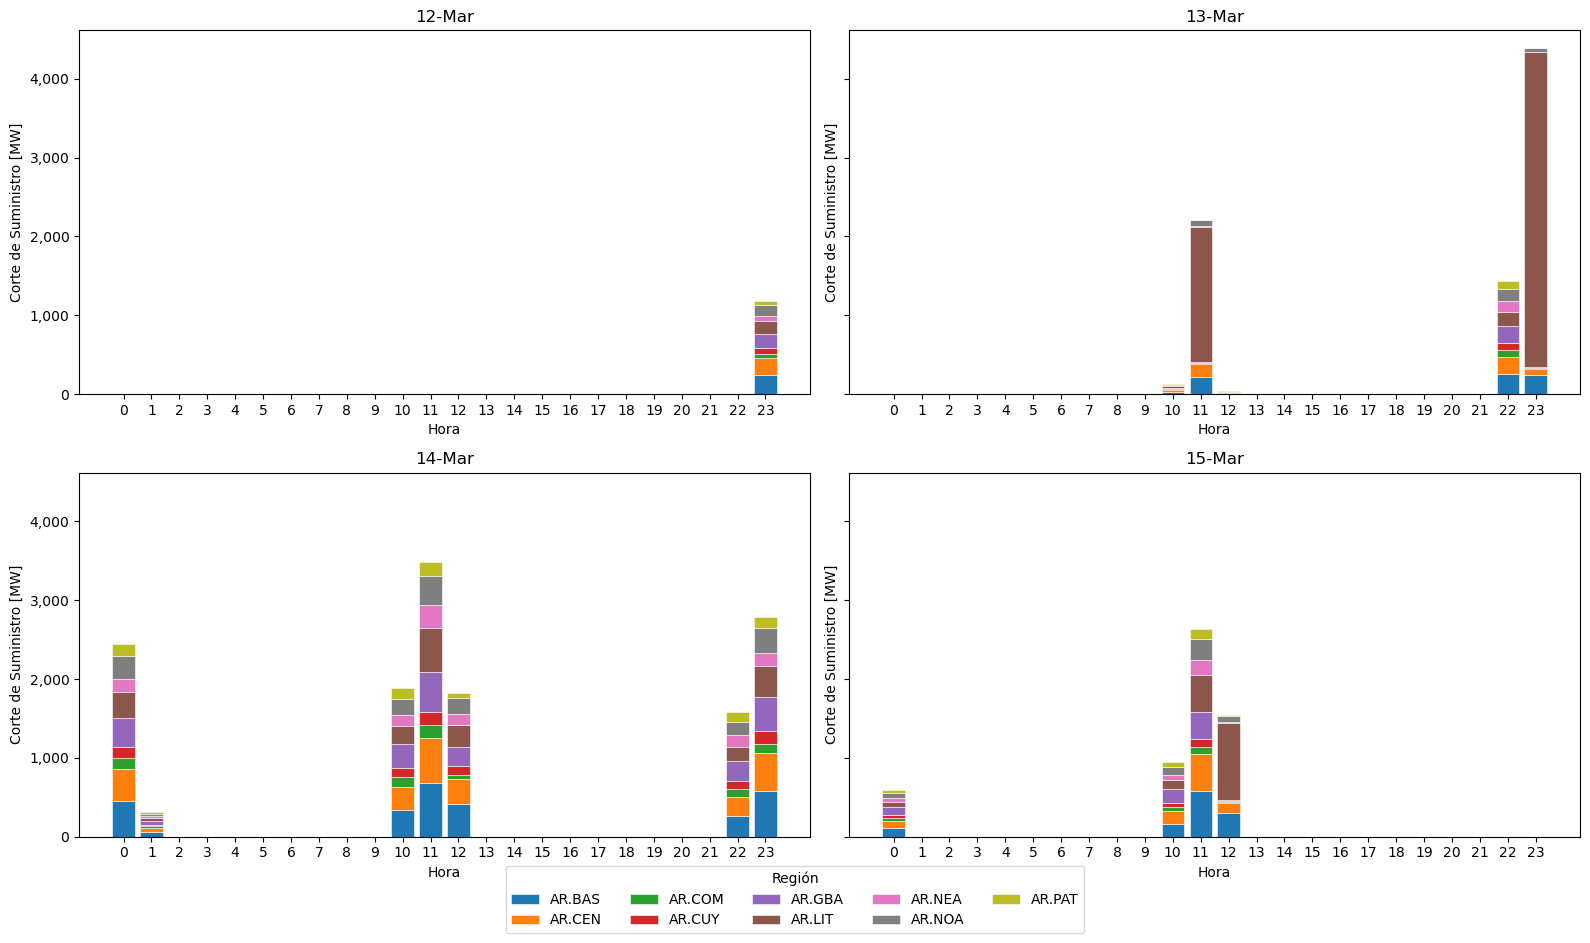


=== Daily Load Shedding Summary ===
            Shedding hours Total shedding [MWh] Peak shedding [MW] Total penalty [$] Avg penalty [$/h]
Day                                                                                                   
2013-03-12               1             1,188.10           1,188.10      4,514,799.95        188,116.66
2013-03-13               5             8,197.28           4,396.07     31,149,736.55      1,297,905.69
2013-03-14               7            14,317.95           3,481.35     54,408,357.71      2,267,014.90
2013-03-15               4             5,706.78           2,629.79     21,685,812.19        903,575.51


In [ ]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

n = #RED

ls_gens = n.generators.index[n.generators.carrier == "load shedding"]
ls_cost = n.generators.loc[ls_gens, "marginal_cost"]

# Per-generator time series (not summed yet)
ls_ts_by_gen = n.generators_t.p[ls_gens]

# Total penalty per snapshot (for threshold filtering)
ls_penalty_ts = (ls_ts_by_gen * ls_cost).sum(axis=1)

PENALTY_THRESHOLD = 1.0
active_snapshots = ls_penalty_ts[ls_penalty_ts > PENALTY_THRESHOLD].index

# Map each generator to its bus (region)
gen_to_bus = n.generators.loc[ls_gens, "bus"]

# Group generators by bus — sum MW across generators sharing the same bus
ls_by_region = ls_ts_by_gen.T.groupby(gen_to_bus).sum().T  # shape: (snapshots, regions)
ls_by_region = ls_by_region.loc[active_snapshots]          # keep only active snapshots

# --- Per-day hourly stacked bar charts ---
days = ["2013-03-12", "2013-03-13", "2013-03-14", "2013-03-15"]

# Build a color palette for regions
regions = ls_by_region.columns.tolist()
colors = plt.cm.tab10.colors[:len(regions)]

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
axes = axes.flatten()

daily_stats = []

for ax, day in zip(axes, days):
    day_range = pd.date_range(start=day, periods=24, freq="h")
    day_data  = ls_by_region.reindex(day_range, fill_value=0)  # shape: (24, regions)

    # Stacked bars — one segment per region
    bottom = pd.Series(0.0, index=range(24))
    for region, color in zip(regions, colors):
        values = day_data[region].values
        ax.bar(range(24), values, bottom=bottom, label=region, color=color,
               edgecolor="white", linewidth=0.4)
        bottom += values

    ax.set_title(pd.Timestamp(day).strftime("%#d-%b"))
    ax.set_xlabel("Hora")
    ax.set_ylabel("Corte de Suministro [MW]")
    ax.set_xticks(range(24))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Stats still based on total across regions
    day_total   = day_data.sum(axis=1)
    day_penalty = (ls_penalty_ts.reindex(day_range, fill_value=0))
    daily_stats.append({
        "Day":                  day,
        "Shedding hours":       int((day_total > 0).sum()),
        "Total shedding [MWh]": f"{day_total.sum():,.2f}",
        "Peak shedding [MW]":   f"{day_total.max():,.2f}",
        "Total penalty [$]":    f"{day_penalty.sum():,.2f}",
        "Avg penalty [$/h]":    f"{day_penalty[day_penalty > 0].mean():,.2f}" if (day_penalty > 0).any() else "—",
    })

# Shared legend outside the subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Región", loc="lower center",
           ncol=min(len(regions), 5), bbox_to_anchor=(0.5, -0.05))


plt.tight_layout()
plt.show()

# --- Daily statistics table ---
stats_df = pd.DataFrame(daily_stats).set_index("Day")
print("\n=== Daily Load Shedding Summary ===")
print(stats_df.to_string())